<a href="https://colab.research.google.com/github/tazir-shaif/ai-engineering-portfolio/blob/main/module-1-prompt-engineering/Session_1_Prompt_Patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 — Prompt Engineering in Code
## Session 1 — Basic Prompt Patterns

In this session we write zero-shot, few-shot, and chain-of-thought
prompts as Python functions and compare their outputs side by side.

Example used: Swiggy customer complaint classification

In [1]:
# Install required libraries
!pip install groq langchain langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.3 MB/s eta 0:00:00


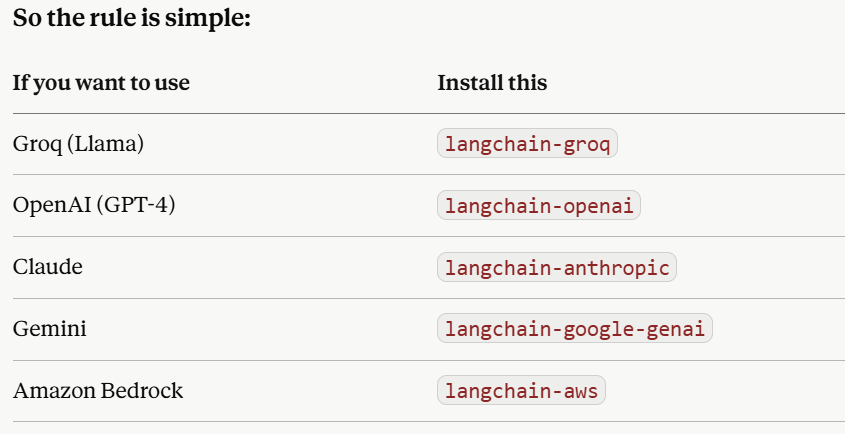

In [2]:
import os
from google.colab import userdata

# Load API key safely from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

# ChatGroq is LangChain's connector for Groq
# This is different from Module 0 where we used Groq directly
# Here we use LangChain's version — same result, but now works with all LangChain features
from langchain_groq import ChatGroq

# Create the model object
# temperature controls creativity — 0 means consistent/predictable answers
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

print("Model ready!")

Model ready!


## Zero-Shot Prompting
Give the AI a task with no examples — just instructions.

In [3]:
# Zero-shot prompt — no examples given, just instruction
# We are asking the AI to classify a Swiggy customer complaint

def zero_shot_classify(complaint):
    # f-string lets us insert the complaint variable into the prompt
    prompt = f"""Classify this Swiggy customer complaint into one of these categories:
    DELIVERY, FOOD_QUALITY, PAYMENT, APP_ISSUE, OTHER

    Complaint: {complaint}

    Reply with just the category name, nothing else."""

    # .invoke() sends the prompt to the model and gets a reply
    # It is LangChain's standard way to call any model
    response = llm.invoke(prompt)

    # response.content extracts just the text reply
    return response.content

# Test it with a sample Swiggy complaint
complaint = "My order was 45 minutes late and the food was cold when it arrived"
result = zero_shot_classify(complaint)
print("Complaint:", complaint)
print("Category:", result)

Complaint: My order was 45 minutes late and the food was cold when it arrived
Category: DELIVERY


## Few-Shot Prompting
Give the AI a few examples before the actual task —
this teaches the AI the pattern we want.

In [4]:
# Few-shot prompt — we give examples before the actual complaint
# This teaches the AI the pattern we expect

def few_shot_classify(complaint):
    prompt = f"""Classify Swiggy customer complaints into categories.
Categories: DELIVERY, FOOD_QUALITY, PAYMENT, APP_ISSUE, OTHER

Here are some examples:
Complaint: "My order never arrived"
Category: DELIVERY

Complaint: "The biryani had a bad smell"
Category: FOOD_QUALITY

Complaint: "I was charged twice for my order"
Category: PAYMENT

Complaint: "The app keeps crashing when I try to order"
Category: APP_ISSUE

Now classify this complaint:
Complaint: {complaint}
Category:"""

    response = llm.invoke(prompt)
    return response.content

# Test with the same complaint
complaint = "My order was 45 minutes late and the food was cold when it arrived"
result = few_shot_classify(complaint)
print("Complaint:", complaint)
print("Category:", result)

Complaint: My order was 45 minutes late and the food was cold when it arrived
Category: Based on the given categories, the complaint "My order was 45 minutes late and the food was cold when it arrived" can be classified into two categories: 

1. DELIVERY (because the order was late)
2. FOOD_QUALITY (because the food was cold when it arrived)

However, if we need to choose one category, it would be more specific to DELIVERY, as the primary issue is the late delivery of the order.


In [5]:
def few_shot_classify(complaint):
    prompt = f"""Classify Swiggy customer complaints into categories.
Categories: DELIVERY, FOOD_QUALITY, PAYMENT, APP_ISSUE, OTHER

A complaint can belong to multiple categories.
Reply with only the category names separated by commas, nothing else.

Here are some examples:
Complaint: "My order never arrived"
Category: DELIVERY

Complaint: "The biryani had a bad smell"
Category: FOOD_QUALITY

Complaint: "I was charged twice for my order"
Category: PAYMENT

Complaint: "The app keeps crashing when I try to order"
Category: APP_ISSUE

Now classify this complaint:
Complaint: {complaint}
Category:"""

    response = llm.invoke(prompt)
    return response.content

# Test with the same complaint
complaint = "My order was 45 minutes late and the food was cold when it arrived"
result = few_shot_classify(complaint)
print("Complaint:", complaint)
print("Category:", result)

Complaint: My order was 45 minutes late and the food was cold when it arrived
Category: DELIVERY, FOOD_QUALITY


## Chain of Thought Prompting
Ask the AI to think step by step before giving the final answer.
This improves accuracy on complex complaints.

In [6]:
# Chain of Thought — we ask the AI to reason step by step
# This is useful for complex complaints with multiple issues

def chain_of_thought_classify(complaint):
    prompt = f"""You are a Swiggy customer support classifier.
Categories: DELIVERY, FOOD_QUALITY, PAYMENT, APP_ISSUE, OTHER

Follow these steps:
Step 1 - Read the complaint carefully
Step 2 - List every problem mentioned in the complaint
Step 3 - Match each problem to a category
Step 4 - Give the final categories as comma separated values

Complaint: {complaint}

Let's think step by step:"""

    response = llm.invoke(prompt)
    return response.content

# Test with the same complaint
complaint = "My order was 45 minutes late and the food was cold when it arrived"
result = chain_of_thought_classify(complaint)
print("Complaint:", complaint)
print("\nReasoning and Category:")
print(result)

Complaint: My order was 45 minutes late and the food was cold when it arrived

Reasoning and Category:
Let's break down the complaint step by step.

**Step 1 - Read the complaint carefully**
The customer is complaining about two issues: 
1. The order was late (45 minutes).
2. The food was cold when it arrived.

**Step 2 - List every problem mentioned in the complaint**
1. Order was late
2. Food was cold

**Step 3 - Match each problem to a category**
1. Order was late - This issue is related to the delivery of the order, so it falls under the **DELIVERY** category.
2. Food was cold - This issue is related to the quality of the food, so it falls under the **FOOD_QUALITY** category.

**Step 4 - Give the final categories as comma separated values**
The final categories are: DELIVERY, FOOD_QUALITY


## Comparison — Zero-Shot vs Few-Shot vs Chain of Thought
We test all three prompt patterns on the same complaints and compare results.

In [7]:
# pandas is Python's most popular library for working with tables of data
# We use it here to display our comparison in a clean table
import pandas as pd

# Test complaints — real Swiggy scenarios
complaints = [
    "My order was 45 minutes late and the food was cold",
    "The app crashed when I tried to pay and money got deducted",
    "Wrong items were delivered and the packaging was damaged"
]

# Run all three methods on each complaint
results = []

for complaint in complaints:
    results.append({
        "Complaint": complaint,
        "Zero-Shot": zero_shot_classify(complaint),
        "Few-Shot": few_shot_classify(complaint),
        "Chain-of-Thought": chain_of_thought_classify(complaint).split("final categories are:")[-1].strip()
    })

# Create a DataFrame — think of it as an Excel table in Python
df = pd.DataFrame(results)

# Display the table
df

,Complaint,Zero-Shot,Few-Shot,Chain-of-Thought
0,My order was 45 minutes late and the food was ...,DELIVERY,"DELIVERY, FOOD_QUALITY","DELIVERY, FOOD_QUALITY"
1,The app crashed when I tried to pay and money ...,APP_ISSUE,"DELIVERY, APP_ISSUE, PAYMENT",Let's break down the complaint step by step:\n...
2,Wrong items were delivered and the packaging w...,DELIVERY,"DELIVERY, FOOD_QUALITY","DELIVERY, FOOD_QUALITY"


In [8]:
# Improved extraction function
def extract_categories(cot_response):
    # Split by common patterns the AI uses to end its reasoning
    for phrase in ["final categories are:", "categories are:", "Category:"]:
        if phrase.lower() in cot_response.lower():
            return cot_response.lower().split(phrase.lower())[-1].strip().upper()
    # If no pattern found, return last line
    return cot_response.strip().split("\n")[-1].upper()

# Rebuild the results with fixed extraction
results = []

for complaint in complaints:
    cot_result = chain_of_thought_classify(complaint)
    results.append({
        "Complaint": complaint,
        "Zero-Shot": zero_shot_classify(complaint),
        "Few-Shot": few_shot_classify(complaint),
        "Chain-of-Thought": extract_categories(cot_result)
    })

df = pd.DataFrame(results)
df

,Complaint,Zero-Shot,Few-Shot,Chain-of-Thought
0,My order was 45 minutes late and the food was ...,DELIVERY,"DELIVERY, FOOD_QUALITY","DELIVERY, FOOD_QUALITY"
1,The app crashed when I tried to pay and money ...,APP_ISSUE,"DELIVERY, APP_ISSUE, PAYMENT","APP_ISSUE, PAYMENT"
2,Wrong items were delivered and the packaging w...,DELIVERY,"DELIVERY, FOOD_QUALITY","DELIVERY, FOOD_QUALITY"


## Key Takeaways
- Zero-shot is fast but misses nuance
- Few-shot improves accuracy by showing examples
- Chain-of-thought gives highest accuracy by forcing step by step reasoning
- Output formatting instructions are critical in every prompt